# Full Method 1 Notebook (Using `main` module)

Refactored to import from the `main` directory.

In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import copy
from pathlib import Path

# Import from main
from main import (
    get_device, set_seed,
    load_participant, get_split_series,
    preprocess_eeg, preprocess_eeg_from_config,
    preprocess_emg, preprocess_emg_from_config, EMGNormalizer,
    preprocess_kinematics, preprocess_kinematics_from_config, KinNormalizer,
    extract_kt, extract_kt_raw,
    WAYEEGDataset,
    KGGTModel, build_kg_gt_from_config, CNN1dAligner,
    build_transformer_only_from_config,
    CombinedEMGLoss, build_loss_from_config,
    train_model, TrainConfig, TrainResult,
    collect_predictions, compute_metrics, EvalMetrics,
    prepare_batch_factory, save_checkpoint, load_checkpoint,
    print_gpu_info,
    compute_muscle_edge_prior,   # for edge-prior computation (follow-up step)
)

ROOT = Path(".")

In [2]:
set_seed(42)
device = get_device()
print(f"Device: {device}")


Device: cuda


In [3]:
CONFIG = {
    "outputs":{
        "figures_dir": "docs/figure/method1",
    },
    "data": {
        "participant": "P2",       
        "data_root": "data/way-eeg/raw",
        "cache_dir": "data/cache_main",
        # window_size=4000 @ 500 Hz = 8 s window; stride=250 = 0.5 s step
        # chunked transformer: 4000 / chunk_size=500 = 8 chunks of 500 → O(500²) not O(4000²)
        "window_size": 500,
        "stride": 100,
        "fs_eeg": 500,                   # Hz
        "fs_emg": 4000,                  # Hz (raw); downsampled to fs_eeg after preprocess
        "fs_kin": 500,                   # Hz
        "n_eeg_channels": 32,
        "n_emg_channels": 5,
        "n_kin_raw": 36,                 # raw kin cols in hs.kin.sig
        "n_kin_features": 26             # k_t dimension after extraction
    },
    "preprocessing": {
        "eeg": {
            "bp_low": 0.5,                  # Hz, bandpass lower bound
            "bp_high": 40.0,                # Hz, bandpass upper bound
            "artifact_method": "ica_auto",  # "asr" | "ica_auto" | "ica_manual"
            "filter_order": 4,
            "notch_freq": 50.0,             # Hz, power-line
            "asr_window_ms": 500,           # ms, ASR sliding window
            "asr_std_thresh": 5.0,          # sigma, ASR rejection threshold
            "delta_low": 0.5,               # Hz, delta-band lower bound
            "delta_high": 40.0,             # Hz, delta-band upper bound
            "use_car": False,
            "use_tkeo": True,
            #"target_channels": ["FC1", "FC2", "C3", "Cz", "C4", "CP1", "CP2", "CP6"]
        },
        "emg": {
            "bp_low": 30.0,              # Hz
            "bp_high": 300.0,            # Hz
            "filter_order": 4,
            "lp_cutoff": 8.0,           # Hz, low-pass for envelope
            "downsample_factor": 8       # 4000 -> 500 Hz
        },
        "kinematics": {
            "include_velocity": True,   # if true, output is (T, 26) = k_t + velocity
            "velocity_method": "sg",     # 'sg' (Savitzky-Golay) | 'bw' (Butterworth diff)
            "sg_window": 11,             # SG window length (samples, must be odd)
            "sg_poly": 3,                # SG polynomial order
            "bw_cutoff": 20.0,           # LP cutoff Hz before diff (used when method='bw')
            "bw_order": 4,               # Butterworth order (used when method='bw')
            "normalize": True            # per-feature z-score over training set
        },
    },
    "model": {
        "type": "transformer_regressor",
        "transformer": {
            "n_layers": 4,
            "n_heads": 8,
            "d_model": 128,
            "d_k": 32,
            "d_v": 32,
            "ffn_dim": 512,
            "dropout": 0.2,
            # chunk_size=500 with window_size=4000 → 8 chunks of 500
            # → O(500²)=250K scores per head (not O(4000²)=16M)
            # MUST divide window_size evenly or a RuntimeWarning fires and
            # full O(T²) attention is used (catastrophically slow).
            "chunk_size": 500
        },
        "gat": {
            "n_layers": 2,
            "node_dim": 64,
            "hidden_dim": 64,
            "heads": 4,
            "dropout": 0.2,
            "use_kinematic_guidance": True,
        },
        "decoder": {
            "out_channels": 5            # predicted EMG channels
        }
    },
    "training": {
        "loss": {
            "peak_alpha":      5.0,    # 3× emphasis on EMG burst peaks vs. baseline silence
            "lambda_reg":      0.001,   # KL anchor strength: GAT edge_bias stays near prior
            "lambda_l1": 0.01,
            "rest_threshold":  0.05,
            "asymmetry": 1.0,
            "use_peak_weight": True,   # set False for ablation back to standard MSE
        },
        # ── optimizer ─────────────────────────────────────────────────────
        "optimizer":   "adamw",   # 'adam' | 'adamw'
        "weight_decay": 1e-3,     # AdamW weight decay (ignored for adam)
        # ── scheduler ─────────────────────────────────────────────────────
        "scheduler":   "cosine",  # 'reduce' | 'cosine'
        # reduce-specific
        "lr_patience": 5,
        "lr_factor":   0.5,
        # cosine-specific
        "cosine_t_max":   None,   # None → use max_epochs
        "cosine_eta_min": 1e-6,
        # ── common ────────────────────────────────────────────────────────
        "loss_lambda":  1.0,      # 1.0 = plain MSE; <1.0 enables Soft-DTW (O(T²), DO NOT use at T=4000)
        "lr":                  1e-4,
        # batch_size=4 with T=4000 keeps VRAM safe on GTX 1660 Ti (6 GB).
        # effective batch = batch_size * gradient_accumulation_steps = 4 * 8 = 32
        # Tune batch_size up (e.g. 8) if VRAM is available; reduce grad_accum_steps proportionally.
        "batch_size":          32,
        "gradient_accumulation_steps": 2,
        "early_stop_patience": 20,
        "grad_clip_norm":      1.0,
        "stage1_epochs":       50,
        "max_epochs":          50,
        # use_amp=True: enables FP16 mixed precision via torch.autocast + GradScaler.
        # GTX 1660 Ti (sm_75 Turing) has FP16 tensor cores → ~1.5-2x speedup.
        # Requires PyTorch >= 2.0. Set False only if you see NaN losses.
        "use_amp":             True,
        "log_memory_every":    50,
        "losocv": True,           # leave-one-subject-out cross-validation
        "checkpoint_every":     1,
        "seed":                42,
    },
    "dataset": {
        # Keep in sync with data.window_size / data.stride above
        "window_size": 500,
        "stride": 100,
    }
}
notebook_cfg = copy.deepcopy(CONFIG)


In [ ]:
import matplotlib.pyplot as plt
from main.dataloader import load_hs
from main.preprocessing_emg_kin import preprocess_emg_from_config
from main.plots import plot_emg_envelope_overlay

# 1. Load the continuous series dictionary
data_path = "data/way-eeg/raw/P2/HS_P2_S1.mat" # Adjust as needed
hs_data = load_hs(data_path) 
emg_raw = hs_data["emg"]
fs_raw = float(hs_data["fs_emg"])
fs_env = 500.0  # Standard downsampled rate

# 2. Process with the Old Method (Rectify + Lowpass)
cfg_old = {"bp_low": 30.0, "bp_high": 300.0, "lp_cutoff": 10.0, "use_tkeo": False}
emg_old = preprocess_emg_from_config(emg_raw, fs=fs_raw, cfg=cfg_old)

# 3. Process with the New Method (TKEO + Lowpass)
# Change the lp_cutoff from 10.0 to 3.0 (or 5.0) to aggressively smooth the envelope!
cfg_new = {"bp_low": 30.0, "bp_high": 300.0, "lp_cutoff": 8.0, "use_tkeo": True}
emg_tkeo = preprocess_emg_from_config(emg_raw, fs=fs_raw, cfg=cfg_new)

# ==========================================
# 4. Slice a 20-second window
# ==========================================
start_sec = 0
end_sec = 10

# Calculate array indices based on sampling rates
start_idx_raw, end_idx_raw = int(start_sec * fs_raw), int(end_sec * fs_raw)
start_idx_env, end_idx_env = int(start_sec * fs_env), int(end_sec * fs_env)

# Apply slices
emg_raw_slice = emg_raw[start_idx_raw:end_idx_raw]
emg_old_slice = emg_old[start_idx_env:end_idx_env]
emg_tkeo_slice = emg_tkeo[start_idx_env:end_idx_env]


# 5. Plot using the built-in overlay function
channel = 1  # Change this to view different muscles

# Set up a figure with 2 subplots (side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
time_env = np.linspace(start_sec, end_sec, len(emg_tkeo_slice))

# ----------------------------------------------------
# 1. Plot the OLD Method Envelope (Rectification)
# ----------------------------------------------------
ax1.plot(time_env, emg_old_slice[:, channel], color="green", linewidth=2.0)
ax1.set_title(f"OLD Method Envelope (Rectify + LP) - Ch {channel + 1}")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Amplitude")
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------
# 2. Plot the NEW Method Envelope (TKEO)
# ----------------------------------------------------
ax2.plot(time_env, emg_tkeo_slice[:, channel], color="red", linewidth=2.0)
ax2.set_title(f"NEW Method Envelope (TKEO + sqrt + LP) - Ch {channel + 1}")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("TKEO Amplitude")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Overlay for the Old Method (First 20s)
fig1 = plot_emg_envelope_overlay(
    raw_emg=emg_raw_slice, 
    env_emg=emg_old_slice, 
    fs_raw=fs_raw, 
    fs_env=fs_env, 
    channel_idx=channel, 
    title=f"Old Method (Rectify) Envelope - Ch {channel + 1} ({start_sec}s - {end_sec}s)"
)

# Overlay for the New TKEO Method (First 20s)
empirical_scale_factor = 6.0 
emg_tkeo_scaled_for_overlay = emg_tkeo_slice * empirical_scale_factor

fig2 = plot_emg_envelope_overlay(
    raw_emg=emg_raw_slice, 
    env_emg=emg_tkeo_scaled_for_overlay, 
    fs_raw=fs_raw, 
    fs_env=fs_env, 
    channel_idx=channel, 
    title=f"New Method (TKEO) Overlay (Scaled by {empirical_scale_factor}x for Visualization)"
)
plt.show()

In [4]:
def make_preprocess_fn(cfg):
    eeg_cfg = cfg["preprocessing"]["eeg"]
    emg_cfg = cfg["preprocessing"]["emg"]
    kin_cfg = cfg["preprocessing"]["kinematics"]
    def preprocess_fn(series):
        series = dict(series)
        series["eeg"] = preprocess_eeg_from_config(
            series["eeg"],
            float(series["fs_eeg"]),
            eeg_cfg,
            channel_names=series.get("eeg_names"),
        )
        series["emg"] = preprocess_emg_from_config(
            series["emg"],
            float(series["fs_emg"]),
            emg_cfg,
        )
        series["kin"] = preprocess_kinematics_from_config(                                           
              series["kin"],                                                                           
              float(series["fs_kin"]),                                                                 
              kin_cfg,                                                                                 
        ) 
        return series

    return preprocess_fn

def build_dataset_split(cfg, participants=None, split="train", root_dir=ROOT):
    data_cfg = cfg["data"]
    if participants is None:
        p_str = data_cfg["participant"]
        p_id = int(p_str.replace("P", "")) if isinstance(p_str, str) else p_str
        participants = [p_id]
        
    return WAYEEGDataset(
        data_dir=root_dir / data_cfg["data_root"],
        participants=participants,
        split=split,
        window_size=cfg["dataset"]["window_size"],
        stride=cfg["dataset"]["stride"],
        preprocess_fn=make_preprocess_fn(cfg),
        cache_dir= root_dir / data_cfg["cache_dir"]
    )

train_ds = build_dataset_split(notebook_cfg, split="train")
val_ds = build_dataset_split(notebook_cfg, split="val")
test_ds = build_dataset_split(notebook_cfg, split="test")

print(train_ds)
print(val_ds)
print(test_ds)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 13.6s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 15.7s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 6.6s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 9.6s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 11.0s.
Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 32 components
Fitting ICA took 11.4s.
Fitting ICA to data using 32 channels (please be patient, th

In [22]:
def unique_series_arrays(ds):
    seen, eegs, kins, emgs = set(), [], [], []
    for eeg_all, kin_all, emg_all, _ in ds._windows:
        key = id(eeg_all)
        if key in seen:
            continue
        seen.add(key)
        eegs.append(eeg_all)
        kins.append(kin_all)
        emgs.append(emg_all)
    return eegs, kins, emgs

train_eegs, train_kins, train_emgs = unique_series_arrays(train_ds)
kin_all = np.concatenate(train_kins, axis=0)
emg_all = np.concatenate(train_emgs, axis=0)

emg_mean = torch.tensor(emg_all.mean(axis=0), dtype=torch.float32, device=device)
emg_std = torch.tensor(emg_all.std(axis=0), dtype=torch.float32, device=device)
kin_mean = torch.tensor(kin_all.mean(axis=0), dtype=torch.float32, device=device)
kin_std = torch.tensor(kin_all.std(axis=0), dtype=torch.float32, device=device)

emg_std = torch.clamp(emg_std, min=1e-6)
kin_std = torch.clamp(kin_std, min=1e-6)

def local_prepare_batch_factory(emg_mean, emg_std, kin_mean, kin_std, device, drop_kin_indices=None):       
    def prepare_batch(eeg, kin, emg):                                                                
        eeg = eeg.to(device, non_blocking=True)
        kin = kin.to(device, non_blocking=True)
        emg = emg.to(device, non_blocking=True)
        
        kin_norm = (kin - kin_mean) / kin_std
        
        # Drop the chosen indices before passing to the model
        if drop_kin_indices is not None:
            keep_idx = [i for i in range(kin_norm.shape[-1]) if i not in drop_kin_indices]
            kin_norm = kin_norm[..., keep_idx]
            
        emg_norm = (emg - emg_mean) / emg_std
        return {"eeg": eeg, "kin": kin_norm}, emg_norm
    return prepare_batch 

# from main.training import prepare_batch_factory

# # 1. Update config dimension (26 - 2 = 24 features)
# CONFIG["data"]["n_kin_features"] = 24

# # 2. Create your batch preparation function dropping both rho_GL and its velocity
# prepare_batch = prepare_batch_factory(device=device, drop_kin_indices=[12, 25])


# 1. Update BOTH config dictionaries (26 total - 2 dropped = 24 remaining)
CONFIG["data"]["n_kin_features"] = 24
if "notebook_cfg" in locals():
    notebook_cfg["data"]["n_kin_features"] = 24

# 2. Drop index 12 (rho_GL) and index 25 (d_rho_GL/dt)
drop_indices = [12, 25]

# 3. Use local factory for proper normalization
prepare_batch = local_prepare_batch_factory(
    emg_mean, emg_std, kin_mean, kin_std, device, drop_kin_indices=drop_indices
)


In [23]:
sample_eeg, sample_kin, sample_emg = train_ds[0]

# Define how many features are dropped
drop_kin_indices = [12, 25]
# Infer dynamically:
dummy_eeg = torch.as_tensor(sample_eeg).unsqueeze(0)
dummy_kin = torch.as_tensor(sample_kin).unsqueeze(0)
dummy_emg = torch.as_tensor(sample_emg).unsqueeze(0)
batch_inputs, _ = prepare_batch(dummy_eeg, dummy_kin, dummy_emg)
true_eeg_dim = batch_inputs["eeg"].shape[-1]
true_kin_dim = batch_inputs["kin"].shape[-1]
true_eeg_dim = sample_eeg.shape[-1]

print("Computing muscle edge prior from training EMG...")
# train_emgs is already extracted in the previous cell!
prior_np = compute_muscle_edge_prior(train_emgs)
edge_prior = torch.from_numpy(prior_np)
print(f"Computed edge prior matrix:\n{prior_np}")

# Build loss
loss_fn = build_loss_from_config(notebook_cfg["training"])
print(f"Loss function: {loss_fn}")

Computing muscle edge prior from training EMG...
Computed edge prior matrix:
[[1.         0.3389561  0.2808829  0.3447394  0.2510012 ]
 [0.3389561  1.         0.75432944 0.90121347 0.7177813 ]
 [0.2808829  0.75432944 1.         0.80380344 0.644748  ]
 [0.3447394  0.90121347 0.80380344 1.         0.6955714 ]
 [0.2510012  0.7177813  0.644748   0.6955714  1.        ]]
Loss function: CombinedEMGLoss(
  (recon): PeakWeightedMSELoss()
  (reg): EdgePriorKLDivLoss()
)


### **Understanding the Output Above: GAT & Edge Prior**

**1. What is the Edge Prior Matrix?**
The matrix printed above is the **empirical Pearson correlation matrix** of the 5 muscle EMG envelopes across the entire training dataset. 
- A value like `0.735` between Muscle 1 and Muscle 2 means they frequently co-activate in the physical data.
- By initializing the learnable `edge_bias` parameter with this matrix (via a log transform), we give the model a physiological "shortcut". Instead of forcing the model to learn the biomechanical structure of the hand blindly, it starts with the knowledge of which muscles naturally fire together.

**2. How does the Graph Attention Network (GAT) use this?**
In our architecture, the 5 muscle groups are treated as nodes in a graph. For every single time step, they communicate to negotiate the final predicted EMG values:
- **Feature Matching**: Each muscle node generates a Query ($Q$) and Key ($K$). Raw similarity is computed as $Q \cdot K^T$.
- **Edge Bias Addition**: The static structural bias is added: `Scores = (Q @ K^T) + edge_bias`.
- **Kinematic Guidance (Dynamic Bias)**: If enabled, the kinematic state $k_t$ is passed through a small MLP to generate a dynamic bias, which is also added. This allows the graph structure to morph depending on the hand's physical state.
- **Softmax & Aggregation**: The final scores are converted to probabilities via Softmax, and used to aggregate the Value ($V$) vectors from other muscles. This ensures physically realistic co-activations in the final regression output.

In [24]:
batch_size = notebook_cfg["training"]["batch_size"]

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                          pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          pin_memory=True, num_workers=0)

In [25]:
import torch
from main.model import build_kg_gt_from_config

test_cfg = {
    "model": {
        "type": "kg_gt_kinematic",
        "transformer": {"n_layers": 2, "n_heads": 4, "d_model": 64, "d_k": 16, "d_v": 16, "ffn_dim": 128, "dropout": 0.1, "chunk_size": 250},
        "gat": {"n_layers": 2, "node_dim": 32, "hidden_dim": 32, "heads": 2, "dropout": 0.1, "use_kinematic_guidance": True},
        "decoder": {"out_channels": 5}
    }
}

m = build_kg_gt_from_config(test_cfg, input_dim=32, kin_dim=13)
x_eeg = torch.randn(2, 500, 32, requires_grad=True)
x_kin = torch.randn(2, 500, 13, requires_grad=True)
out = m(x_eeg, x_kin)

loss = out.pow(2).mean()
loss.backward()

print("Output shape:", out.shape) # Should be torch.Size([2, 500, 5])
print("Skip projection (layer 0) grad norm:", m.kin_skip_proj[0].weight.grad.norm().item())
print("Skip projection (layer 2) grad norm:", m.kin_skip_proj[2].weight.grad.norm().item())


Output shape: torch.Size([2, 500, 5])
Skip projection (layer 0) grad norm: 0.029857352375984192
Skip projection (layer 2) grad norm: 0.2239142805337906


In [26]:
# 1. Grab a single sample from the training dataset
sample_eeg, sample_kin, sample_emg = train_ds[0]
print(f"Raw dataset kinematic shape:      {sample_kin.shape}  (Expected: 26 features)")

# 2. Pass it through prepare_batch (adding dummy batch dimension with .unsqueeze(0))
inputs, targets = prepare_batch(
    sample_eeg.unsqueeze(0), 
    sample_kin.unsqueeze(0), 
    sample_emg.unsqueeze(0)
)

out_kin_shape = inputs["kin"].shape[-1]
print(f"Prepared batch kinematic shape:   {inputs['kin'].shape}  (Expected: 24 features)")

# 3. Automatic assertions to be 100% sure
assert sample_kin.shape[-1] - out_kin_shape == 2, "Error: Did not drop exactly 2 features!"
assert out_kin_shape == CONFIG["data"]["n_kin_features"], f"Error: Config expects {CONFIG['data']['n_kin_features']} features, but got {out_kin_shape}!"

Raw dataset kinematic shape:      torch.Size([500, 26])  (Expected: 26 features)
Prepared batch kinematic shape:   torch.Size([1, 500, 24])  (Expected: 24 features)


In [28]:
# ============================================================================
# Stage 1: Pre-train Transformer-Only Model
# ============================================================================
print("--- STAGE 1: Transformer Pre-training ---")
from main import build_transformer_only_from_config
stage1_model = build_transformer_only_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim
).to(device)

# ── DYNAMIC SUBJECT STRING FIX ───────────────────────────────────────
p_val = notebook_cfg["data"].get("participant", notebook_cfg["data"].get("participants", [1]))
p_id = p_val[0] if isinstance(p_val, (list, tuple)) else p_val
subject_str = f"P{str(p_id).replace('P', '')}"
print(f"Active subject: {subject_str}")
# ─────────────────────────────────────────────────────────────────────

# ── DIMENSION & SHAPE VERIFICATION CHECK ─────────────────────────────
print("\n" + "═"*60)
print("RUNNING PRE-TRAINING DIMENSION & SHAPE CHECK")
print("═"*60)

# 1. Grab a single test batch from DataLoader
_raw_eeg, _raw_kin, _raw_emg = next(iter(train_loader))
print(f"1. Raw Loader Batch Shapes:")
print(f"   • EEG:         {list(_raw_eeg.shape)} (Batch, Time, Channels)")
print(f"   • Kinematics:  {list(_raw_kin.shape)} (Batch, Time, Raw Kin Features)")
print(f"   • Target EMG:  {list(_raw_emg.shape)} (Batch, Time, Muscle Channels)")

# 2. Test prepare_batch (normalization + feature dropping)
_inputs, _targets = prepare_batch(_raw_eeg, _raw_kin, _raw_emg)
print(f"\n2. Prepared Model Inputs (after prepare_batch):")
print(f"   • Input EEG:   {list(_inputs['eeg'].shape)} [device: {_inputs['eeg'].device}]")
print(f"   • Input Kin:   {list(_inputs['kin'].shape)} [device: {_inputs['kin'].device}] -> (Verify dropped indices!)")
print(f"   • Target EMG:  {list(_targets.shape)} [device: {_targets.device}]")

# 3. Verify Forward Pass & Model compatibility
stage1_model.eval()
with torch.no_grad():
    _out = stage1_model(**_inputs)
print(f"\n3. Model Output Verification:")
print(f"   • Output Shape: {list(_out.shape)} (Should match Target EMG)")

# 4. Automated Safety Assertions
assert _inputs["eeg"].shape[-1] == true_eeg_dim, f"EEG dimension mismatch! Expected {true_eeg_dim}, got {_inputs['eeg'].shape[-1]}"
assert _inputs["kin"].shape[-1] == notebook_cfg["data"]["n_kin_features"], f"Kinematic features mismatch! Config expects {notebook_cfg['data']['n_kin_features']}, but prepared batch has {_inputs['kin'].shape[-1]}"
assert _out.shape == _targets.shape, f"Model output shape {list(_out.shape)} does not match target shape {list(_targets.shape)}!"

print("\nALL DIMENSIONS & SHAPE CHECKS PASSED! PROCEEDING TO TRAINING...")
print("═"*60 + "\n")
# ─────────────────────────────────────────────────────────────────────

train_cfg_stage1 = TrainConfig.from_config(
    notebook_cfg["training"], 
    max_epochs=notebook_cfg["training"]["stage1_epochs"]
)
# Automatically saves to: outputs/checkpoints_main_stage1/P2
train_cfg_stage1.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + f"_stage1/{subject_str}"

result_stage1 = train_model(
    model=stage1_model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg_stage1,
    resume=False
)

--- STAGE 1: Transformer Pre-training ---
Active subject: P2

════════════════════════════════════════════════════════════
RUNNING PRE-TRAINING DIMENSION & SHAPE CHECK
════════════════════════════════════════════════════════════
1. Raw Loader Batch Shapes:
   • EEG:         [32, 500, 32] (Batch, Time, Channels)
   • Kinematics:  [32, 500, 26] (Batch, Time, Raw Kin Features)
   • Target EMG:  [32, 500, 5] (Batch, Time, Muscle Channels)

2. Prepared Model Inputs (after prepare_batch):
   • Input EEG:   [32, 500, 32] [device: cuda:0]
   • Input Kin:   [32, 500, 24] [device: cuda:0] -> (Verify dropped indices!)
   • Target EMG:  [32, 500, 5] [device: cuda:0]

3. Model Output Verification:
   • Output Shape: [32, 500, 5] (Should match Target EMG)

ALL DIMENSIONS & SHAPE CHECKS PASSED! PROCEEDING TO TRAINING...
════════════════════════════════════════════════════════════

  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capabi

  Ep    1 [train]:   0%|          | 0/380 [00:00<?, ?batch/s]

  Ep    1 [val  ]:   0%|          | 0/65 [00:00<?, ?batch/s]

  Ep    2 [train]:   0%|          | 0/380 [00:00<?, ?batch/s]

  Ep    2 [val  ]:   0%|          | 0/65 [00:00<?, ?batch/s]

...

  Ep   49 [train]:   0%|          | 0/380 [00:00<?, ?batch/s]

  Ep   49 [val  ]:   0%|          | 0/65 [00:00<?, ?batch/s]

  Ep   50 [train]:   0%|          | 0/380 [00:00<?, ?batch/s]

  Ep   50 [val  ]:   0%|          | 0/65 [00:00<?, ?batch/s]


Training done.  Best val loss = 1.7313
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints_main_stage1\P2


Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\history_stage_1_pretraining.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\history_stage_1_pretraining.pdf


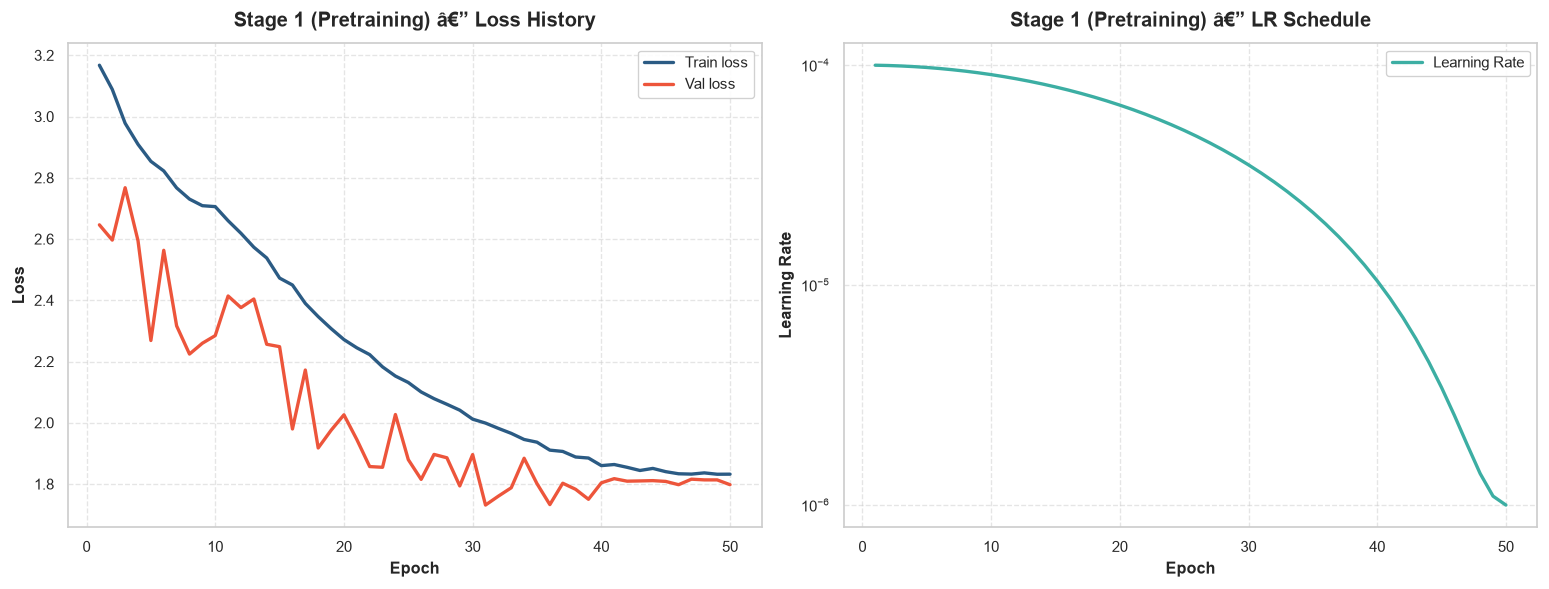

In [29]:
from main import plot_training_history
import matplotlib.pyplot as plt

# Plot Loss & LR curves for Stage 1 (Automatically saves to results/P{x}/.../plots/history_stage_1_pretraining.png)
fig_stage1 = plot_training_history(
    history=result_stage1.history,
    stage="Stage 1 (Pretraining)",
    cfg=notebook_cfg
)
plt.show()


In [30]:
model = build_kg_gt_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim,
    kin_dim=true_kin_dim,
    edge_prior=edge_prior
).to(device)

In [31]:
# ============================================================================
# Stage 2: Train Full KG-GT Model with Frozen Transformer
# ============================================================================
print("\n--- STAGE 2: GAT Training (Frozen Transformer) ---")

# Load Transformer & NodeProjection weights from Stage 1
best_stage1_state = result_stage1.best_state
if best_stage1_state is not None:
    filtered_state = {k: v for k, v in best_stage1_state.items() if k.startswith("encoder.") or k.startswith("node_projection.")}
    model.load_state_dict(filtered_state, strict=False)
    print("Loaded pretrained Transformer weights into KGGTModel.")


# 1. Freeze ALL layers initially
for param in model.parameters():
    param.requires_grad = False
    
# 2. Unfreeze GAT, Decoder, and the new Kinematic Skip Highway
for param in model.gat.parameters():
    param.requires_grad = True
for param in model.decoder.parameters():
    param.requires_grad = True
if hasattr(model, "kin_skip_proj") and model.kin_skip_proj is not None:
    for param in model.kin_skip_proj.parameters():
        param.requires_grad = True
        
# 3. Unfreeze TOP TRANSFORMER LAYER & NODE PROJECTION for neural co-adaptation
for param in model.encoder.layers[-1].parameters():
    param.requires_grad = True
for param in model.node_projection.parameters():
    param.requires_grad = True

# ── DYNAMIC SUBJECT STRING FIX ───────────────────────────────────────
p_val = notebook_cfg["data"].get("participant", notebook_cfg["data"].get("participants", [1]))
p_id = p_val[0] if isinstance(p_val, (list, tuple)) else p_val
subject_str = f"P{str(p_id).replace('P', '')}"
print(f"Active subject: {subject_str}")
# ─────────────────────────────────────────────────────────────────────

train_cfg_stage2 = TrainConfig.from_config(
    notebook_cfg["training"], 
    max_epochs=notebook_cfg["training"]["max_epochs"]
)
# Automatically saves to: outputs/checkpoints_main_stage2/P2
train_cfg_stage2.checkpoint_dir = notebook_cfg["training"].get("checkpoint_dir", "outputs/checkpoints_main") + f"_stage2/{subject_str}"

result_stage2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    prepare_batch=prepare_batch,
    loss_fn=loss_fn,
    device=device,
    cfg=train_cfg_stage2,
    resume=False,
)


--- STAGE 2: GAT Training (Frozen Transformer) ---
Loaded pretrained Transformer weights into KGGTModel.
Active subject: P2
  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 1187.9 MB
  OK  VRAM reserved   : 3070.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active
  Optimizer : ADAMW  (weight_decay=0.001)
  Scheduler : COSINE  (T_max=50, eta_min=1e-06)

Starting fresh training run  (checkpoint_dir=outputs/checkpoints_main_stage2/P2)



  Ep    1 [train]:   0%|          | 0/380 [00:00<?, ?batch/s]

  Ep    1 [val  ]:   0%|          | 0/65 [00:00<?, ?batch/s]

  Ep    2 [train]:   0%|          | 0/380 [00:00<?, ?batch/s]

  Ep    2 [val  ]:   0%|          | 0/65 [00:00<?, ?batch/s]

...

  Ep   29 [train]:   0%|          | 0/380 [00:00<?, ?batch/s]

  Ep   29 [val  ]:   0%|          | 0/65 [00:00<?, ?batch/s]

  Ep   30 [train]:   0%|          | 0/380 [00:00<?, ?batch/s]

  Ep   30 [val  ]:   0%|          | 0/65 [00:00<?, ?batch/s]

Early stop at epoch 30 (no val improvement for 20 epochs).

Training done.  Best val loss = 0.7194
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\outputs\checkpoints_main_stage2\P2


Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\history_stage_2_gat_finetuning.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\history_stage_2_gat_finetuning.pdf


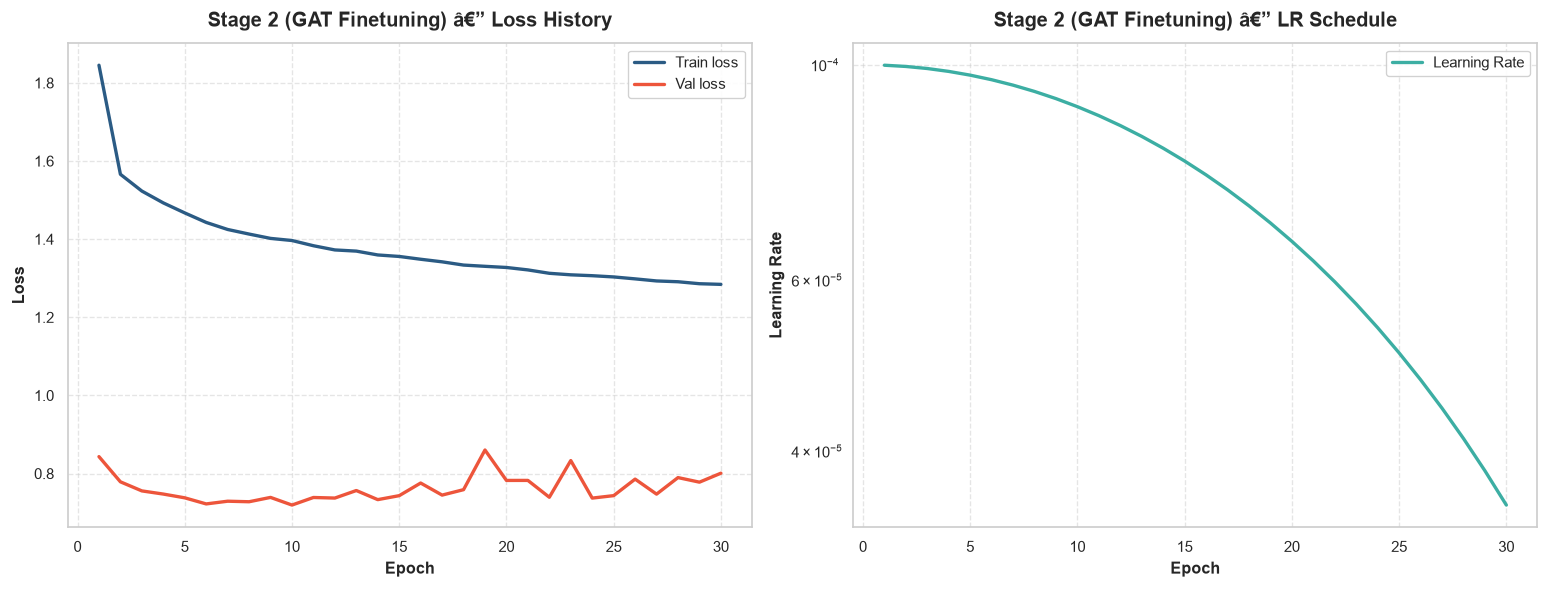

In [32]:
from main import plot_training_history
import matplotlib.pyplot as plt

# Plot Loss & LR curves for Stage 2 (Automatically saves to results/P{x}/.../plots/history_stage_2_gat_finetuning.png)
fig_stage2 = plot_training_history(
    history=result_stage2.history,
    stage="Stage 2 (GAT Finetuning)",
    cfg=notebook_cfg
)
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION — Full metric suite: RMSE, nRMSE, MAE, Pearson r, R^2, VAF
# ─────────────────────────────────────────────────────────────────────────────
import copy, torch
import numpy as np
import pandas as pd
from main import collect_predictions, compute_metrics, load_checkpoint

EMG_NAMES = ["FDI", "APB", "ADM", "ECR", "FCR"]   # adjust to your dataset labels

# Load LAST checkpoint into a fresh copy of the model
best_model = copy.deepcopy(model)

p_val = notebook_cfg["data"].get("participant", notebook_cfg["data"].get("participants", [1]))
p_id = p_val[0] if isinstance(p_val, (list, tuple)) else p_val
subject_str = f"P{str(p_id).replace('P', '')}"

best_ckpt = f"outputs/checkpoints_main_stage2/{subject_str}/best.pt"
print(f"Loading checkpoint from: {best_ckpt}")
load_checkpoint(best_ckpt, best_model, device)


best_model.eval()
# Collect predictions on the held-out test set (stacks all batches)
P_test, Y_test = collect_predictions(
    best_model, test_loader, prepare_batch, device,
    n_channels=len(EMG_NAMES), use_amp=notebook_cfg["training"]["use_amp"],
)
# Compute all 6 metrics (fully vectorised, float64 internally)
metrics = compute_metrics(P_test, Y_test, channel_names=EMG_NAMES)

# Print the publication-ready ASCII table
print("\n" + metrics.as_table() + "\n")

# Pandas DataFrame for export / further analysis
rows = list(zip(
    metrics.channel_names,
    metrics.rmse, metrics.nrmse, metrics.mae,
    metrics.pearson, metrics.r2, metrics.vaf,
))
df = pd.DataFrame(rows,
    columns=["Channel", "RMSE", "nRMSE%", "MAE", "Pearson r", "R^2", "VAF%"])
df.loc["MEAN"] = ["MEAN"] + [df[c].mean() for c in df.columns[1:]]
#display(df.round(4))

# Publication threshold check (VAF > 80% per Winter 1990)
vaf_pass = int((metrics.vaf >= 80.0).sum())
print(f"\nVAF >= 80% threshold: {vaf_pass}/{len(EMG_NAMES)} channels")


Loading checkpoint from: outputs/checkpoints_main_stage2/P2/best.pt
Loaded checkpoint <- outputs/checkpoints_main_stage2/P2/best.pt  (best_val=0.7194)

Channel                RMSE   nRMSE%      MAE  Pearson r      R^2     VAF%
--------------------------------------------------------------------------
FDI                  0.1752     8.86   0.1037     0.9034   0.8054    80.88
APB                  0.3684     6.24   0.2792     0.9423   0.8654    88.65
ADM                  0.6172     5.18   0.4347     0.8489   0.7092    71.41
ECR                  0.3874     6.98   0.2908     0.9402   0.8722    88.34
FCR                  0.5468     6.17   0.3277     0.8577   0.6828    71.08
--------------------------------------------------------------------------
 MEAN                0.4190     6.69   0.2872     0.8985   0.7870    80.07



,Channel,RMSE,nRMSE%,MAE,Pearson r,R^2,VAF%
0,FDI,0.1752,8.8630,0.1037,0.9034,0.8054,80.8814
1,APB,0.3684,6.2388,0.2792,0.9423,0.8654,88.6516
2,ADM,0.6172,5.1844,0.4347,0.8489,0.7092,71.4059
3,ECR,0.3874,6.9802,0.2908,0.9402,0.8722,88.3430
4,FCR,0.5468,6.1683,0.3277,0.8577,0.6828,71.0766
MEAN,MEAN,0.4190,6.6869,0.2872,0.8985,0.7870,80.0717



VAF >= 80% threshold: 3/5 channels


Raw EEG attention shape: (8, 5000, 5000)  (H, T, T)
Kinematic edge bias shape: (5000, 4, 5, 5)  (T, H, N, N)


d:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\main\plots.py:598: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\interpretability_triptych.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\interpretability_triptych.pdf
Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\kin_skip_over_time.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\kin_skip_over_time.pdf


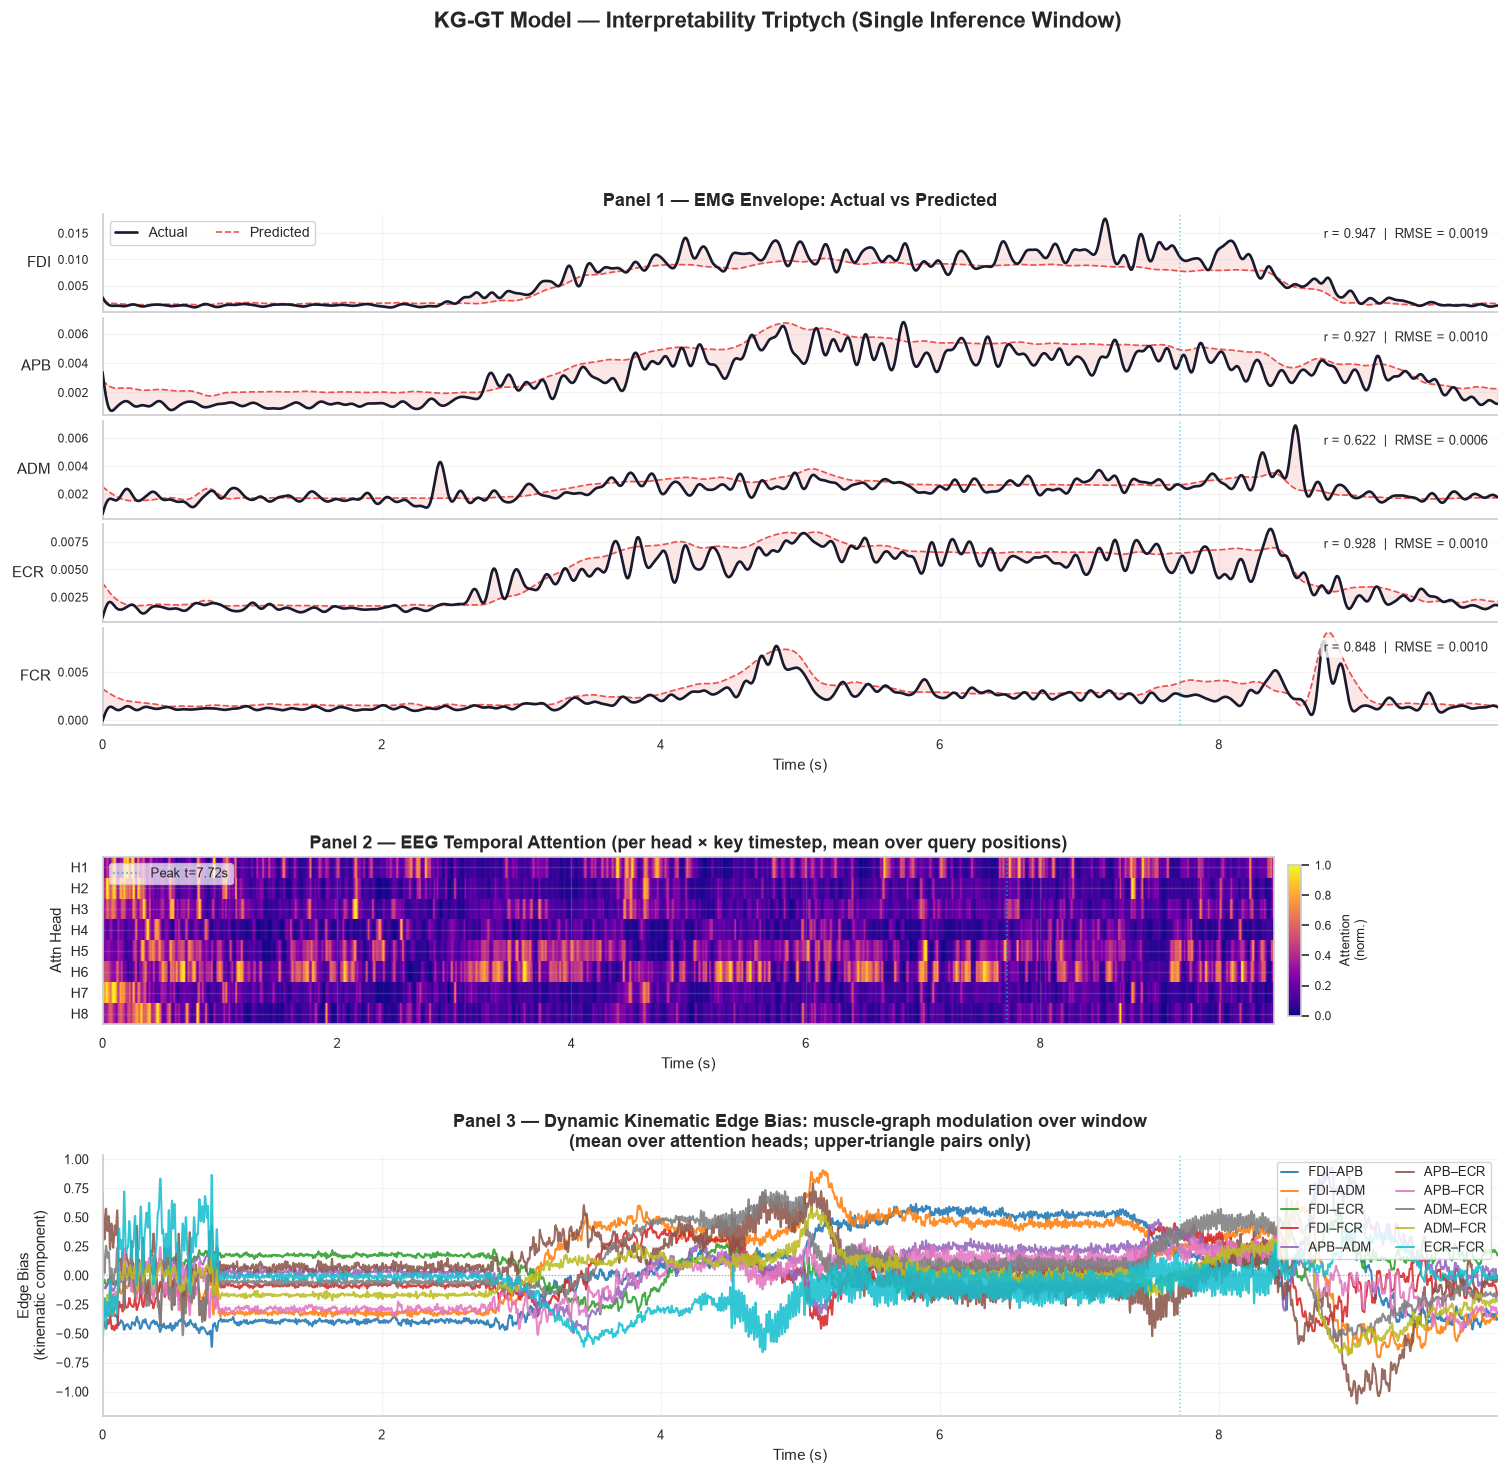

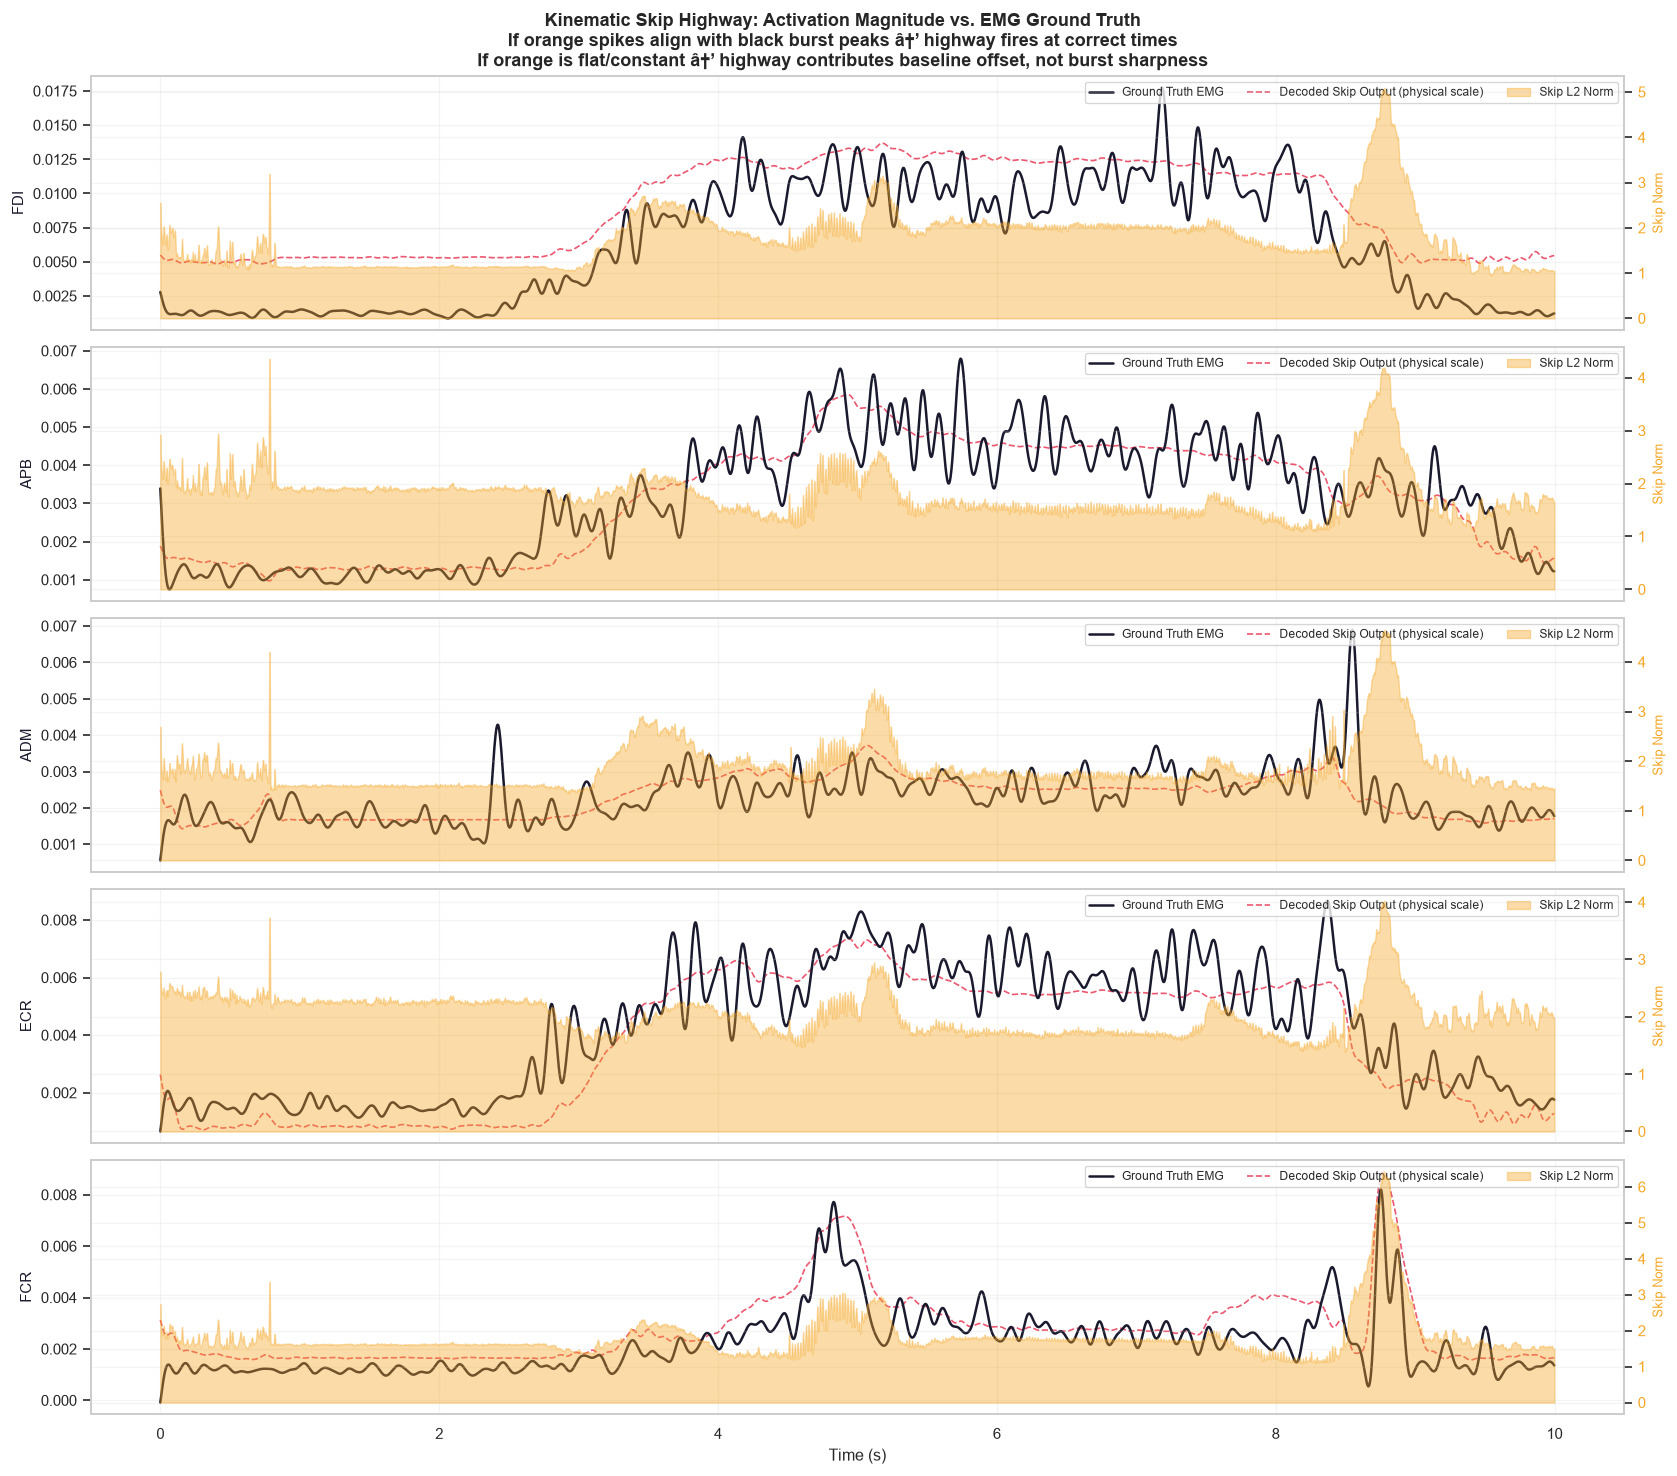

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# INTERPRETABILITY — Dynamic Continuous Window (True Scale)
# ─────────────────────────────────────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt
from main.plots import plot_interpretability_triptych
from main.plots import plot_kin_skip_over_time
from scipy.signal import butter, sosfiltfilt

# REMOVED "rho_GL" because it is dropped in prepare_batch (now 12 features)
KIN_FEATURE_NAMES = [          
    "p_wrist_x", "p_wrist_y", "p_wrist_z",
    "p_index_x", "p_index_y", "p_index_z",
    "p_thumb_x", "p_thumb_y", "p_thumb_z",
    "d_grip",    "F_L",        "F_G",    
]

# ── TIMELINE SELECTION ────────────────────────────────────────────
start_sec = 0.0   # Start plotting from this second
end_sec   = 10.0  # End plotting at this second
# ──────────────────────────────────────────────────────────────────

fs = CONFIG["data"].get("fs_eeg", 500.0)

# 1. Get the underlying continuous array from the dataset's first series
eeg_full, kin_full, emg_full, block_start_idx = test_ds._windows[0]

# 2. Slice based on the selected seconds
start_idx = block_start_idx + int(start_sec * fs)
end_idx   = block_start_idx + int(end_sec * fs)

raw_eeg = torch.tensor(eeg_full[start_idx : end_idx])
raw_kin = torch.tensor(kin_full[start_idx : end_idx])
raw_emg = torch.tensor(emg_full[start_idx : end_idx])

# 3. Add batch dimension (B=1) and normalize properly via prepare_batch
model_inputs, emg_norm = prepare_batch(
    raw_eeg.unsqueeze(0), 
    raw_kin.unsqueeze(0), 
    raw_emg.unsqueeze(0)
)

eeg_b = model_inputs["eeg"]
kin_b = model_inputs["kin"]
emg_b = emg_norm

# 4. Run the model on the custom time window
best_model.eval()

# Inject visualization temperature to SMOOTHEN the heatmap (Must be > 1.0)
for layer in best_model.encoder.layers:
    layer.mhsa.attention_temperature = 4.0

with torch.no_grad():
    pred_b = best_model(eeg_b, kin_b)

# 5. Convert to numpy and UN-NORMALIZE back to true physical scale
pred_np = pred_b[0].cpu().float().numpy()   
true_np = emg_b[0].cpu().float().numpy()    

emg_mean_np = emg_mean.cpu().numpy()
emg_std_np = emg_std.cpu().numpy()
pred_np = pred_np * emg_std_np + emg_mean_np
true_np = true_np * emg_std_np + emg_mean_np

# ── NEW: Post-processing smoothing (5Hz low-pass filter) ──────────
fs = CONFIG["data"].get("fs_eeg", 500.0)
sos = butter(4, 5.0 / (fs / 2.0), btype="low", output="sos")
pred_np = sosfiltfilt(sos, pred_np, axis=0)
# ──────────────────────────────────────────────────────────────────

# 6. Extract EEG temporal attention: (1, H, T, T) -> (H, T, T)

eeg_attn_np = best_model.encoder.layers[-1].mhsa.last_attn_weights[0].cpu().float().numpy()
print(f"Raw EEG attention shape: {eeg_attn_np.shape}  (H, T, T)")

from scipy.ndimage import gaussian_filter1d

eeg_attn_np = gaussian_filter1d(eeg_attn_np, sigma=3.0, axis=-1)

# 7. Extract dynamic kinematic edge bias
if hasattr(best_model.gat, "last_kin_edge_bias"):
    kin_edge_np = best_model.gat.last_kin_edge_bias[0].cpu().float().numpy()
    print(f"Kinematic edge bias shape: {kin_edge_np.shape}  (T, H, N, N)")
else:
    raise RuntimeError("last_kin_edge_bias not found. Set use_kinematic_guidance=True.")

# 8. Generate the 3-panel interpretability money plot
fig = plot_interpretability_triptych(
    pred=pred_np,
    target=true_np,
    eeg_attn=eeg_attn_np,
    kin_edge_bias=kin_edge_np,
    muscle_names=EMG_NAMES,
    kin_feature_names=KIN_FEATURE_NAMES,
    fs=fs,
    cfg=CONFIG,
)

# ── DIAGNOSTIC: Kinematic Skip Highway Activation vs EMG ──────────────────

from main.plots import plot_kin_skip_over_time

fig = plot_kin_skip_over_time(
    model      = best_model,
    eeg_window = eeg_b,
    kin_window = kin_b,
    emg_target = true_np,     # physical scale
    emg_mean   = emg_mean,
    emg_std    = emg_std,
    smooth_hz  = 10.0,        # ← low-pass at 10 Hz; set None to disable
    emg_names  = EMG_NAMES,
    fs         = fs,
    cfg        = CONFIG,
)
plt.show()


Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\residual_decomposition.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\residual_decomposition.pdf


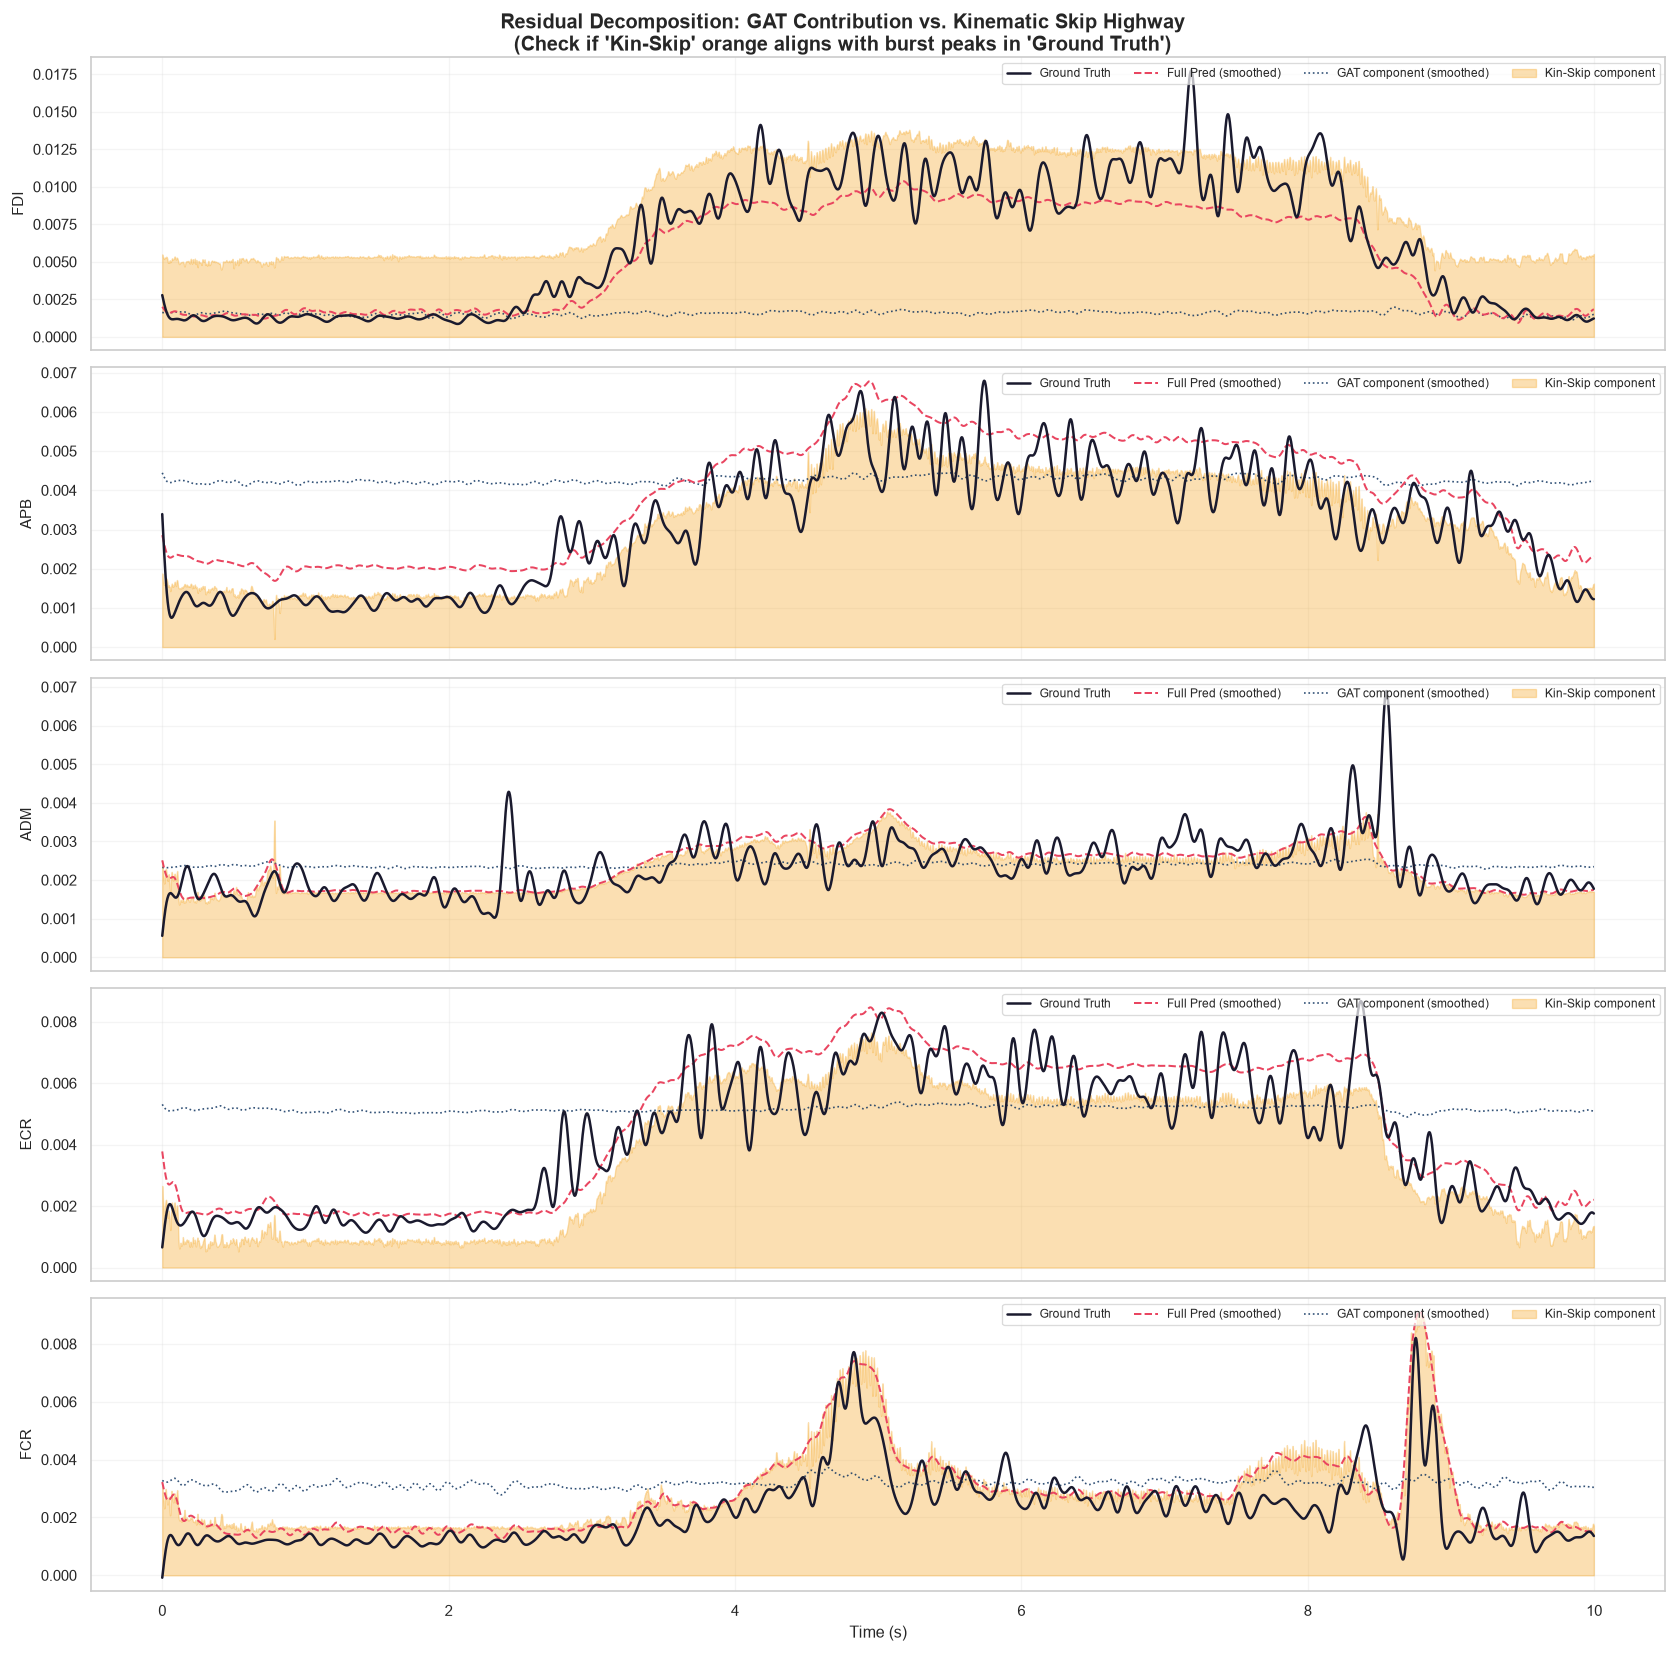

In [35]:
# ── DIAGNOSTIC: Residual Decomposition (GAT vs Kinematic Skip) ────────────
from main.plots import plot_residual_decomposition

fig = plot_residual_decomposition(
    model      = best_model,
    eeg_window = eeg_b,          # Tensor (1, T, 32)
    kin_window = kin_b,          # Tensor (1, T, 13)
    emg_target = true_np,        # np.ndarray (T, 5) — physical scale
    emg_mean   = emg_mean,       # ← NEW: un-normalizes model outputs to physical scale
    emg_std    = emg_std,        # ← NEW
    smooth_hz  = 10.0,           # optional low-pass Hz (set None to disable smoothing)
    emg_names  = EMG_NAMES,
    fs         = fs,
    cfg        = CONFIG,
)
plt.show()



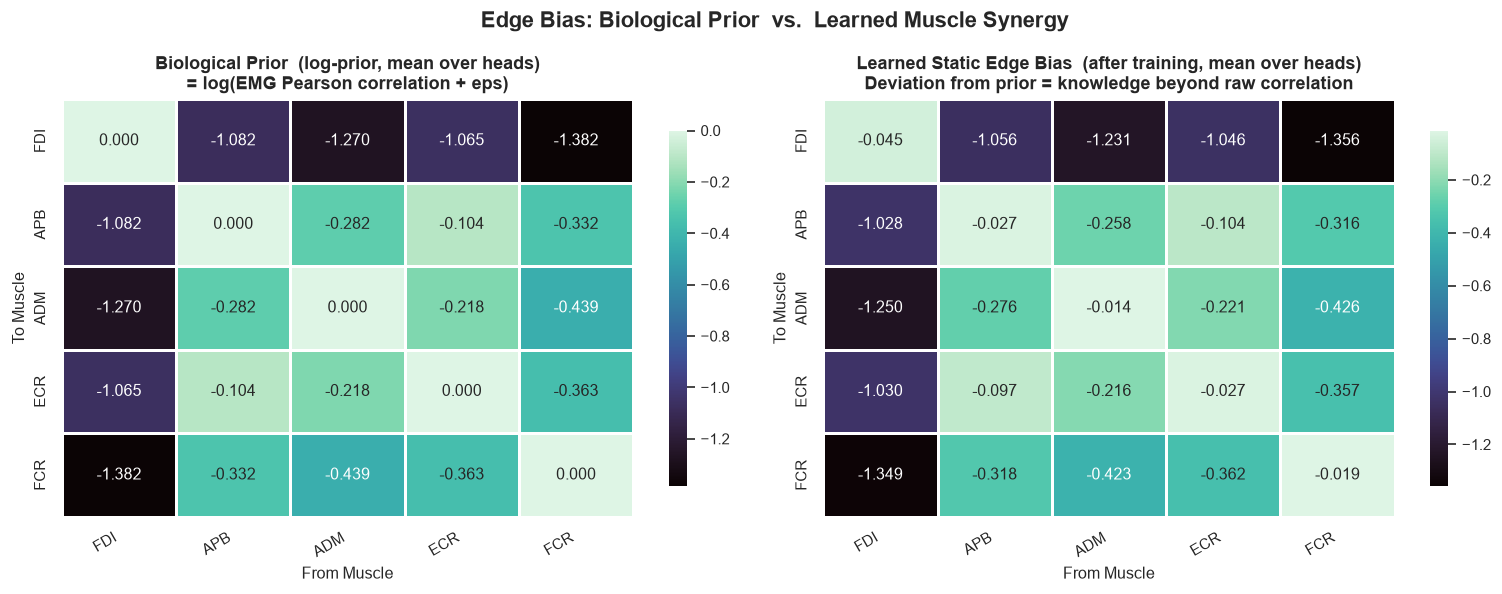

findfont: Failed to find font weight semibold, now using 700.


Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\muscle_synergy_matrix.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\muscle_synergy_matrix.pdf


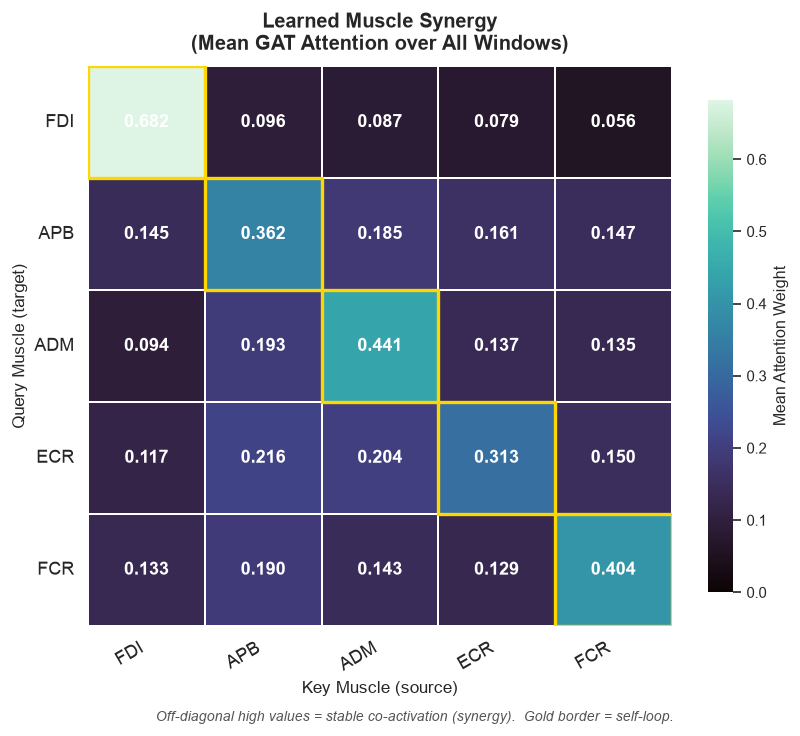

Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\channel_correlation_matrix.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\channel_correlation_matrix.pdf


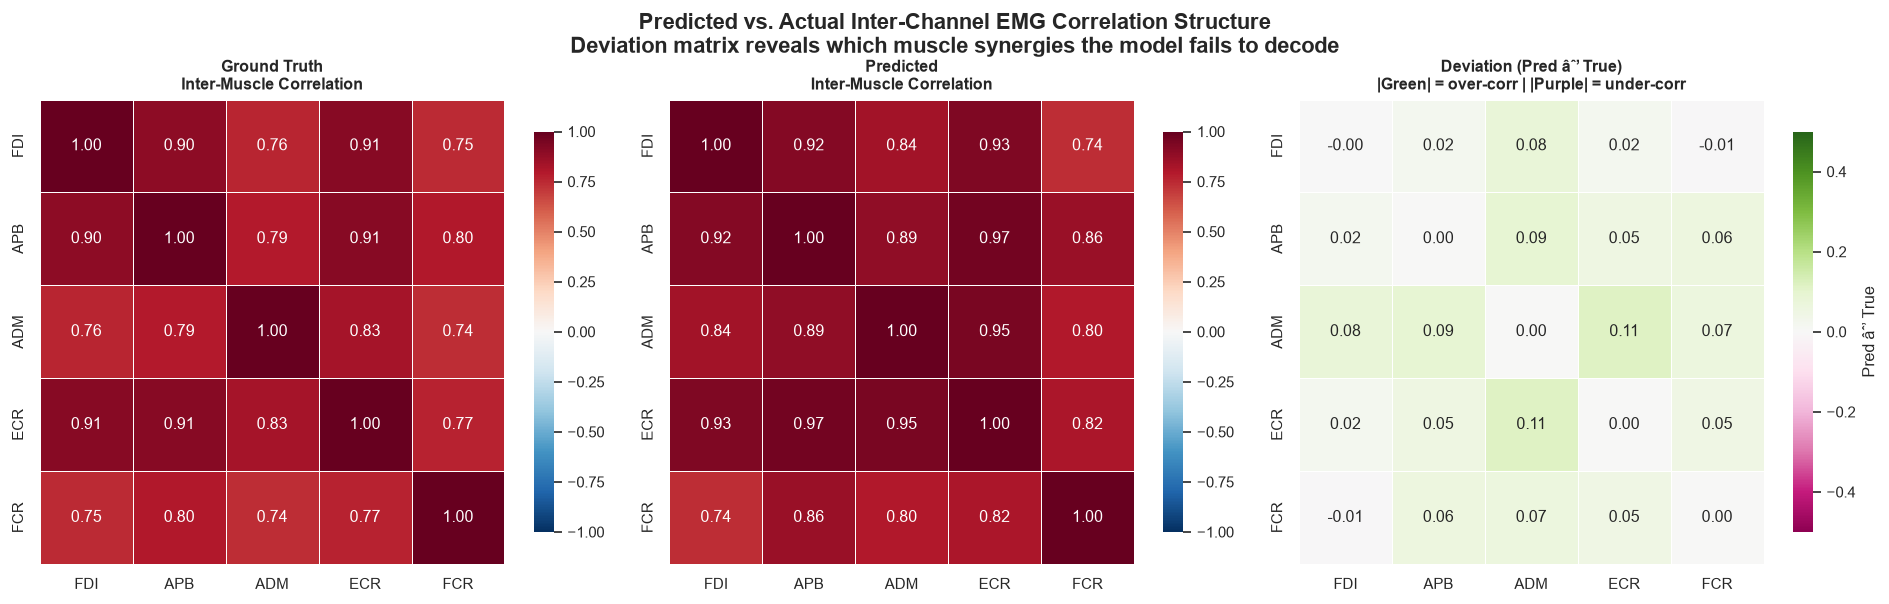

Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\emg_error_analysis.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\emg_error_analysis.pdf


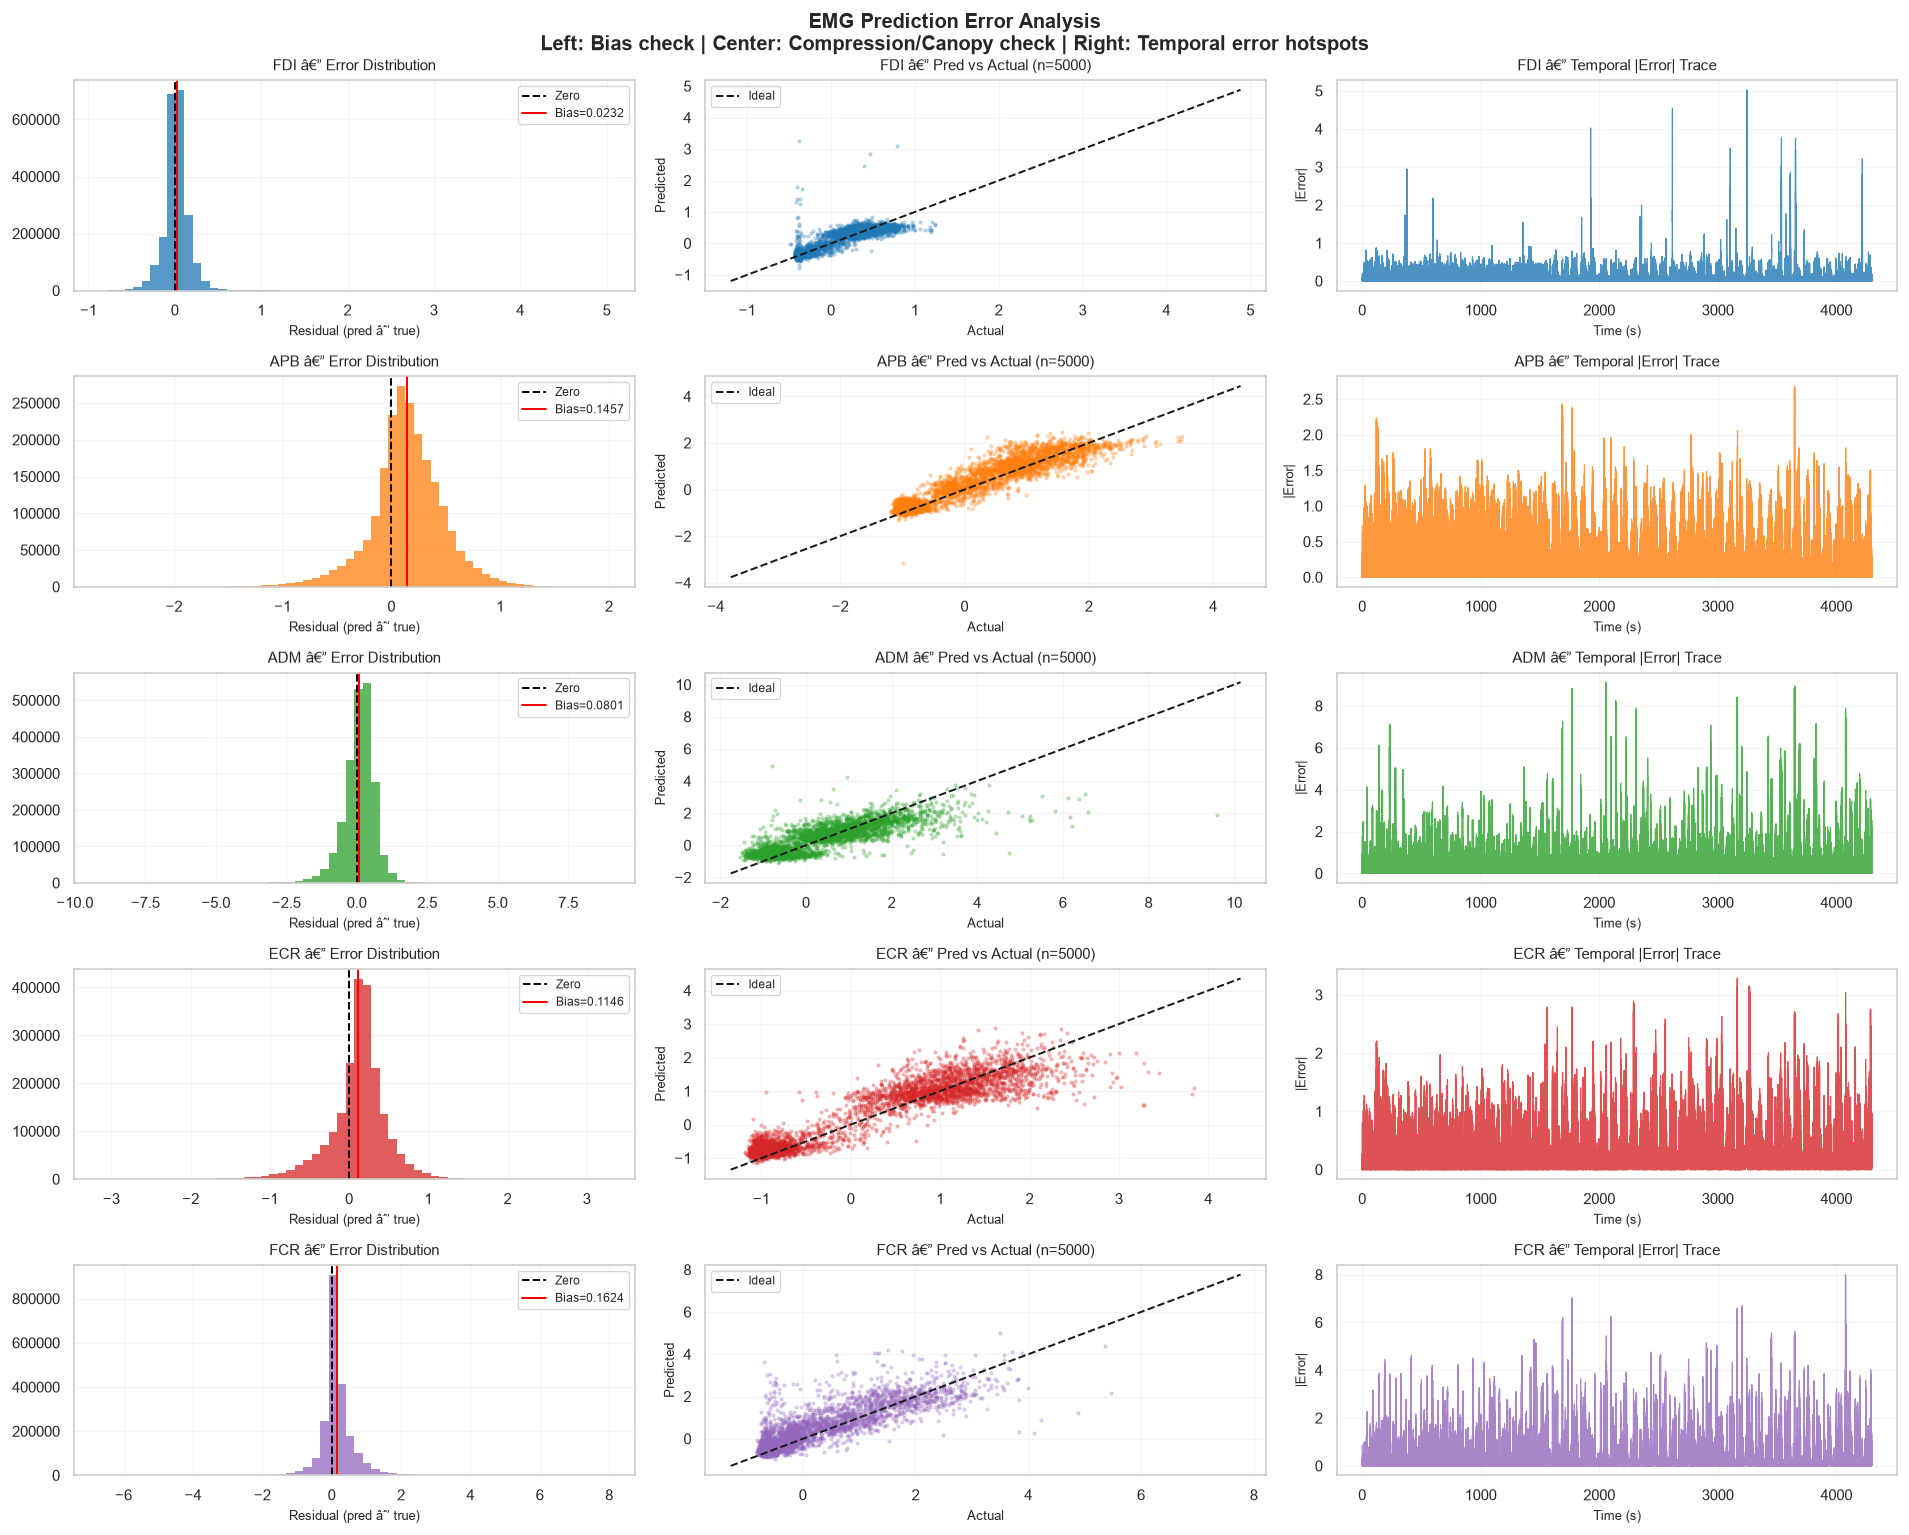

Saved figure:
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\kin_edge_linear_weights.png
  results\P2\main\ep50_st100_lr0.0001_bs32\plots\kin_edge_linear_weights.pdf


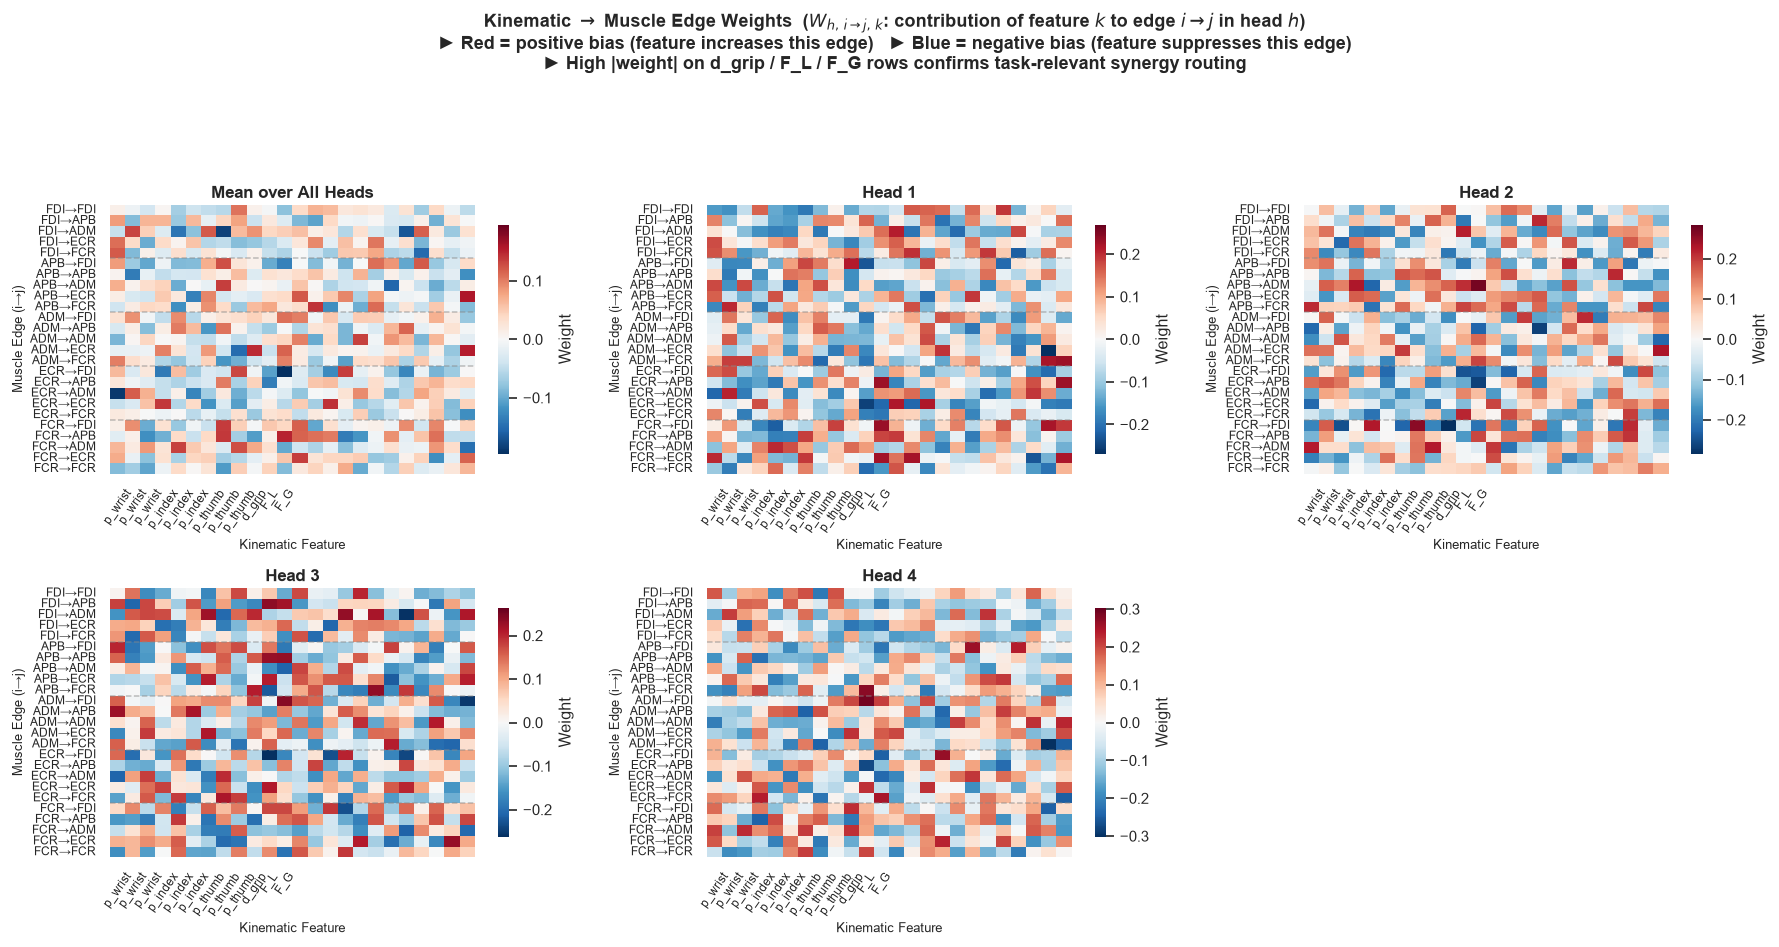


Inspect high |weight| rows on d_grip / F_L / F_G for key insights.


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# STATIC EDGE BIAS + MUSCLE SYNERGY MATRIX + KINEMATIC WEIGHT HEATMAP
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from main import plot_muscle_synergy_matrix, plot_kin_edge_linear_weights

# ── 1. Biological prior vs. learned static edge bias ──────────────────────
gat = best_model.gat
learned_bias = gat.edge_bias.detach().cpu().numpy()    # (H, N, N)
prior_anchor  = gat.edge_prior_anchor.cpu().numpy()    # (H, N, N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
kw = dict(
    annot=True, fmt=".3f", cmap="mako",
    xticklabels=EMG_NAMES, yticklabels=EMG_NAMES,
    cbar_kws={"shrink": 0.85}, linewidths=0.8, linecolor="white",
)
sns.heatmap(prior_anchor.mean(0), ax=axes[0], **kw)
axes[0].set_title(
    "Biological Prior  (log-prior, mean over heads)\n"
    "= log(EMG Pearson correlation + eps)", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("From Muscle"); axes[0].set_ylabel("To Muscle")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.heatmap(learned_bias.mean(0), ax=axes[1], **kw)
axes[1].set_title(
    "Learned Static Edge Bias  (after training, mean over heads)\n"
    "Deviation from prior = knowledge beyond raw correlation",
    fontsize=11, fontweight="bold",
)
axes[1].set_xlabel("From Muscle"); axes[1].set_ylabel("To Muscle")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.suptitle(
    "Edge Bias: Biological Prior  vs.  Learned Muscle Synergy",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

# ── 2. GAT attention synergy matrix (full test set) ───────────────────────
all_attn = []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        # IMPORTANT: Pass through prepare_batch to drop rho_GL (13->12) and normalize!
        model_inputs, _ = prepare_batch(raw_eeg, raw_kin, raw_emg)
        
        # Now pass the properly processed inputs to the model
        best_model(
            model_inputs["eeg"],
            model_inputs["kin"],
        )
        if hasattr(best_model.gat, "last_attn_weights"):
            all_attn.append(best_model.gat.last_attn_weights.cpu().numpy())

if all_attn:
    all_attn_np = np.concatenate(all_attn, axis=0)   # (B*T, H, N, N)
    fig_syn = plot_muscle_synergy_matrix(all_attn_np, EMG_NAMES, cfg=CONFIG)
    plt.show()

# ── DIAGNOSTIC: Predicted vs Actual Inter-Muscle Correlation ──────────────
from main.plots import plot_channel_correlation_matrix

# Collect all predictions and targets from the test loader
all_preds_list, all_targets_list = [], []
best_model.eval()
with torch.no_grad():
    for raw_eeg, raw_kin, raw_emg in test_loader:
        model_inputs, emg_norm = prepare_batch(raw_eeg, raw_kin, raw_emg)
        pred = best_model(model_inputs["eeg"], model_inputs["kin"])
        all_preds_list.append(pred.cpu().float().numpy())
        all_targets_list.append(emg_norm.cpu().float().numpy())

all_preds_flat   = np.concatenate(all_preds_list,   axis=0).reshape(-1, len(EMG_NAMES))
all_targets_flat = np.concatenate(all_targets_list, axis=0).reshape(-1, len(EMG_NAMES))

fig = plot_channel_correlation_matrix(
    y_pred     = all_preds_flat,
    y_true     = all_targets_flat,
    emg_names  = EMG_NAMES,
    cfg        = CONFIG,
)
plt.show()

# ── DIAGNOSTIC: EMG Error Analysis (Bias / Canopy / Temporal Hotspots) ────
from main.plots import plot_emg_error_analysis

fig = plot_emg_error_analysis(
    y_pred    = all_preds_flat,
    y_true    = all_targets_flat,
    emg_names = EMG_NAMES,
    fs        = fs,
    cfg       = CONFIG,
)
plt.show()



# ── 3. Transparent kinematic -> edge weight matrix ────────────────────────
if hasattr(best_model.gat, "kin_edge_linear"):
    W = best_model.gat.kin_edge_linear.weight.detach().cpu().numpy()
    gat_cfg = CONFIG["model"]["gat"]
    fig_kin = plot_kin_edge_linear_weights(
        weight_matrix=W,
        muscle_names=EMG_NAMES,
        kin_feature_names=KIN_FEATURE_NAMES,
        num_heads=gat_cfg["heads"],
        n_nodes=5,
        cfg=CONFIG,
    )
    plt.show()
    print("\nInspect high |weight| rows on d_grip / F_L / F_G for key insights.")
else:
    print("kin_edge_linear not found (use_kinematic_guidance may be False).")
